In [62]:
import numpy as np
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator) :
    # fit() 메소드는 아무것도 학습하지 않음
    def fit(selt,X,y=None) :
        pass
    
    def predict(self,X) :
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]) :
            if X['Sex'].iloc[i] == 1 :
                pred[i] = 0
            else :
                pred[i] = 1
                
        return pred
    
    


In [63]:
from sklearn.preprocessing import LabelEncoder


# Null 처리 함수
def fillna(df) :
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    return df

# 불필요한 컬럼 제거 함수
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 함수
def encode_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features  = ['Cabin','Embarked', 'Sex']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = encode_features(df)
    return df



In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

titanic_df = pd.read_csv('../2장/titanic_train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived',axis=1,inplace=False)

X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train,y_test = train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=0)

myclf = MyDummyClassifier()
myclf.fit(X_train,y_train)
pred = myclf.predict(X_test)
print('Dummy Classifier 정확도는 {0:.4f}'.format(accuracy_score(y_test,pred)))


Dummy Classifier 정확도는 0.7877


In [65]:
from sklearn.datasets import load_digits

class MyFakeClassifier(BaseEstimator) :
    def fit(self,X,y):
        pass
    
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)
    
digits = load_digits()

print(digits.data)
print(digits.data.shape)
print(digits.target)
print(digits.target.shape)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
(1797, 64)
[0 1 2 ... 8 9 8]
(1797,)


In [66]:
digits.target == 7

array([False, False, False, ..., False, False, False], shape=(1797,))

In [67]:
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data,y,random_state=11)

In [68]:
print('레이블 테스트 세트 크기 ', y_test.shape)
print(pd.Series(y_test).value_counts())

fakeclf = MyFakeClassifier()
fakeclf.fit(X_train,y_train)
pred = fakeclf.predict(X_test)
print("모든 예측을 0으로 하여도 정확도는 {:.3f}".format(accuracy_score(y_test,pred)))


레이블 테스트 세트 크기  (450,)
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는 0.900


**Confusion Matrix**

In [69]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,pred)

array([[405,   0],
       [ 45,   0]])

### 정밀도(Precision)과 재현율(Recall)

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print('정밀도 :' ,precision_score(y_test,pred))
print('재현율 :',recall_score(y_test,pred))

정밀도 : 0.0
재현율 : 0.0


**오차행렬,정확도,정밀도,재현율을 한꺼번에 계산하는 함수 생성**

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test,pred) :
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy,precision,recall))
    

In [72]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

titanic_df = pd.read_csv('../2장/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived',axis=1)
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=11)

lr_clf = LogisticRegression(solver='liblinear')

lr_clf.fit(X_train,y_train)
pred= lr_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


### Precision/Recall Trade-Off

**predict_proba()메소드 확인**

In [73]:
pred_proba = lr_clf.predict_proba(X_test) # 2차원
pred = lr_clf.predict(X_test) # 1차원

print('predict_proba() 결과 Shape :{0}'.format(pred_proba.shape))
print('array에서 앞에 3개만 추출 : \n',pred_proba[:3])

pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1,1)], axis=1) # 2차원으로 reshape
print('두개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n',pred_proba_result[:3])

predict_proba() 결과 Shape :(179, 2)
array에서 앞에 3개만 추출 : 
 [[0.44935225 0.55064775]
 [0.86335511 0.13664489]
 [0.86429643 0.13570357]]
두개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935225 0.55064775 1.        ]
 [0.86335511 0.13664489 0.        ]
 [0.86429643 0.13570357 0.        ]]


**Binarizer 활용** 

In [74]:
from sklearn.preprocessing import Binarizer

X = [
    [1, -1, 2],
    [2, 0 , 0],
    [0, 1.1, 1.2]
    ]

# threshold 기준값보다 같거나 작으면 0을, 크면 1을 반환
binarize = Binarizer(threshold= 1.1)
print(binarize.fit_transform(X))


[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


**분류 결정 임계값 0.5 기반에서 Binarizer를 이용하여 예측값 변환**

In [75]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.5

pred_proba_1 = pred_proba[:,1].reshape(-1,1)

binarize = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarize.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


**분류 결정 임계값을 0.4로 조정**

In [76]:
custom_threshold = 0.4

pred_proba_1 = pred_proba[:,1].reshape(-1,1)

binarize = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarize.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


**여러개의 분류 결정 임곗값을 변경하면서 Binarizer를 이용하여 예측값 변환**

In [77]:
# 테스트를 수행할 모든 임곗값을 리스트 객체로 저장. 
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test , pred_proba_c1, thresholds):
    # thresholds list객체내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1) 
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:',custom_threshold)
        get_clf_eval(y_test , custom_predict)

get_eval_by_threshold(y_test ,pred_proba[:,1].reshape(-1,1), thresholds )

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


**precision_recall_curve()를 이용하여 임곗값에 따른 정밀도-재현율 값 추출**

In [78]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일때의 예측 확률을 추출 
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1] 

# 실제값 데이터 셋과 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력 
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1 )
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)
print('반환된 precisions 배열의 Shape:', precisions.shape)
print('반환된 recalls 배열의 Shape:', recalls.shape)

print("thresholds 5 sample:", thresholds[:5])
print("precisions 5 sample:", precisions[:5])
print("recalls 5 sample:", recalls[:5])

#반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출. 
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값 
print('샘플 임계값별 정밀도: ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율: ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (165,)
반환된 precisions 배열의 Shape: (166,)
반환된 recalls 배열의 Shape: (166,)
thresholds 5 sample: [0.01974988 0.06956415 0.0840281  0.08474207 0.08920162]
precisions 5 sample: [0.34078212 0.34269663 0.34463277 0.34659091 0.34857143]
recalls 5 sample: [1. 1. 1. 1. 1.]
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도:  [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율:  [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


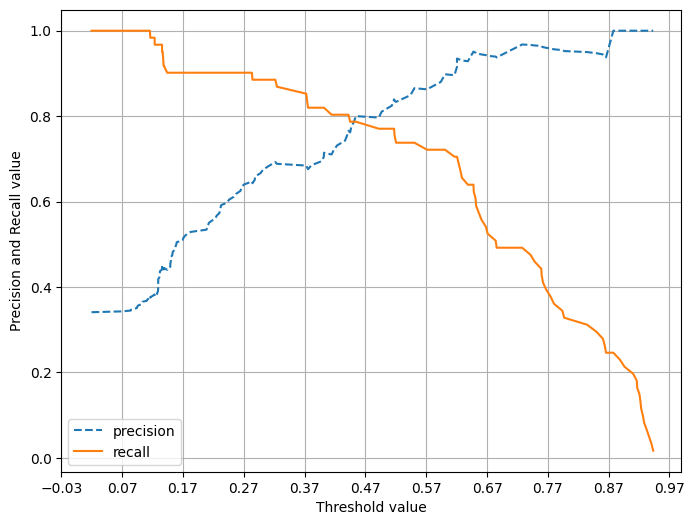

In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출. 
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()
    
precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )

### F1 Score

In [81]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test,pred)
print(f"f1 스코어 : {np.round(f1,4)}")

f1 스코어 : 0.7966


In [84]:
def get_clf_eval(y_test,pred) :
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1 : {3:.4f}'.format(accuracy,precision,recall,f1))
    
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1), thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1 : 0.7576
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1 : 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1 : 0.7966
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1 : 0.7965
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1 : 0.8000


### ROC Curve와 AUC

In [ ]:
from sklearn.metrics import roc_curve


pred_proba_class1 = lr_clf.predict_proba(X_test)[:,1]

fprs, tprs, thresholds = roc_curve(y_test,pred_proba_class1)

thr_index = np.arange(1,thresholds.shape[0],5)
print("샘플 추출을 위한 임곗값 배열의 index : ",thr_index)
print("샘플 index로 추출한 임곗값 : ", np.round(thresholds[thr_index],2))

print('FPR', np.round(fprs[thr_index],3))
print('TPR', np.round(tprs[thr_index],3))

샘플 추출을 위한 임곗값 배열의 index :  [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값 :  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
FPR [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
TPR [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


In [99]:
fprs, tprs, thresholds

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00847458, 0.00847458, 0.01694915, 0.01694915, 0.02542373,
        0.02542373, 0.02542373, 0.04237288, 0.04237288, 0.05932203,
        0.05932203, 0.07627119, 0.07627119, 0.10169492, 0.10169492,
        0.12711864, 0.12711864, 0.16949153, 0.16949153, 0.20338983,
        0.20338983, 0.25423729, 0.25423729, 0.3220339 , 0.34745763,
        0.55932203, 0.57627119, 0.59322034, 0.59322034, 0.60169492,
        0.60169492, 0.61016949, 0.61864407, 0.66101695, 0.6779661 ,
        0.69491525, 0.74576271, 0.77966102, 0.8220339 , 0.8220339 ,
        0.84745763, 0.84745763, 1.        ]),
 array([0.        , 0.01639344, 0.03278689, 0.06557377, 0.24590164,
        0.24590164, 0.49180328, 0.49180328, 0.63934426, 0.63934426,
        0.67213115, 0.70491803, 0.70491803, 0.72131148, 0.72131148,
        0.73770492, 0.73770492, 0.7704918 , 0.7704918 , 0.78688525,
        0.78688525, 0.80327869, 0.80327869, 0.81967213, 0.81967213,
  

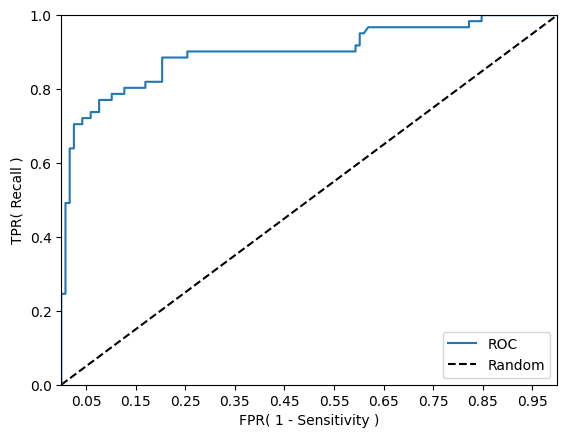

In [100]:
def roc_curve_plot(y_test , pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환 받음. 
    fprs , tprs , thresholds = roc_curve(y_test ,pred_proba_c1)

    # ROC Curve를 plot 곡선으로 그림. 
    plt.plot(fprs , tprs, label='ROC')
    # 가운데 대각선 직선을 그림. 
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
    # FPR X 축의 Scale을 0.1 단위로 변경, X,Y 축명 설정등   
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()
    
roc_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1] )

In [102]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,pred_proba)

print("ROC AUC 값 : {0:.4f}".format(roc_score))

ROC AUC 값 : 0.8987


In [103]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))